In [1]:
import numpy as np
import numpy.random as npr
import matplotlib.pyplot as plt

In [ ]:
def gauss_elimination(A:np.ndarray,b:np.ndarray):
    b = b.reshape(-1,1)
    Ab = np.float64(np.hstack([A,b]))
    row,_ = Ab.shape
    scale_vector = np.max(np.abs(A),axis=1)
    for i in range(row):
        ratios = np.abs(Ab[i:,i])/scale_vector[i:] 
        idx = np.argmax(ratios) + i 
        
        Ab[[i,idx]] = Ab[[idx,i]]
        scale_vector[[i, idx]] = scale_vector[[idx, i]]

        for j in range(row):
            if j>i:
                factor = Ab[j,i]/Ab[i,i]
                Ab[j,:] -= factor*Ab[i,:] 
    return Ab

def back_sub(Ab):
    N = Ab.shape[0]
    x = np.zeros(N)
    for i in range(0,N)[::-1]:
        x[i] = Ab[i,-1]
        for j in range(i+1,N):
            x[i] -= Ab[i,j]*x[j]
        x[i] /= Ab[i,i]
    return x

def solve_linear(A,b):
    Ab_triangular = gauss_elimination(A,b)
    x = back_sub(Ab_triangular)
    return x

In [368]:
def RK4(f,X0,t0,tn,N,*args):
    ts,h = np.linspace(t0,tn,N,retstep = True)
    x = X0
    x_arr = []
    for t in ts:
        x_arr.append(x.copy() if isinstance(x,np.ndarray) else x)
        K1 = h*f(t,x,*args)
        K2 = h*f(t+0.5*h,x+0.5*K1,*args)
        K3 = h*f(t+0.5*h,x+0.5*K2,*args)
        K4 = h*f(t+h,x+K3,*args)
        x += (1/6)*(K1+2*(K2+K3)+K4)
    return np.array(x_arr),ts


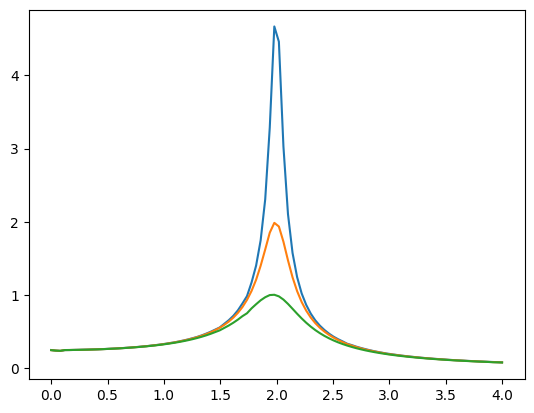

In [369]:
f = lambda t,x : -2*x**2*t

def harmonic(t,X,gamma,w,A):
    x,v = X
    return np.array([v,-4*x-gamma*v + A*np.cos(w*t)])


freq = np.linspace(0,4,100)
gammas = np.array([0.1,0.25,0.50])
for gamma in gammas:
    amp = []
    for w in freq:
        xs,ts = RK4(harmonic,np.array([0.,1.]),0,150,500,gamma,w,1.0)
        xs = np.array(xs)
        x,v = xs.T
        amp.append(np.max(np.abs(x[int(0.8*len(x))::])))
    plt.plot(freq,amp)
plt.show()

In [66]:
A = np.array([[2,10],[1,1]])
b = np.array([1,2])

In [67]:
x = solve_linear(A,b).reshape(-1,1)
A@x

array([[1.],
       [2.]])

In [365]:
from scipy.optimize import fsolve

def implicit_euler(f,y0,t0,tn,N):
    ts,h = np.linspace(t0,tn,N,retstep = True)
    y_old = y0
    y_arr = [np.array(y0)]#y_old.copy() if isinstance(y_old,np.ndarray) else y_old]
    for i in range(len(ts)-1):
        fn = lambda y : y - y_old - h*f(ts[i+1],y)
        y_new = fsolve(fn,y_old)[0]
        y_arr.append(y_new.copy())
        y_old = y_new
    return ts,y_arr




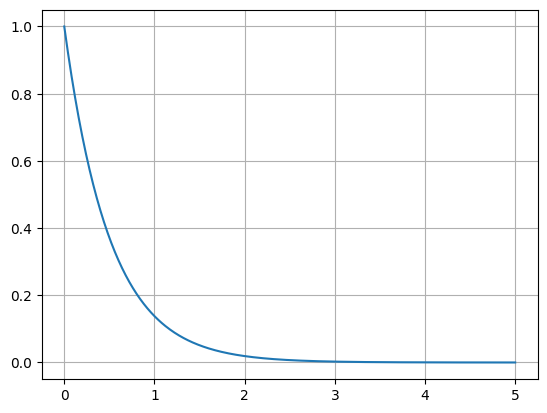

In [425]:
f = lambda t,x : -2*x

t,x = implicit_euler(f,1,0,5,500)

plt.plot(t,x)
plt.grid(1)
plt.show()

## PDE solving using finite difference method

In [10]:
# Laplaces Equation: 

a,b = 0.5,0.5
m=n=4
x,h = np.linspace(0,a,m+1,endpoint=True,retstep=True)
y,k = np.linspace(0,b,n+1,endpoint=True,retstep=True)


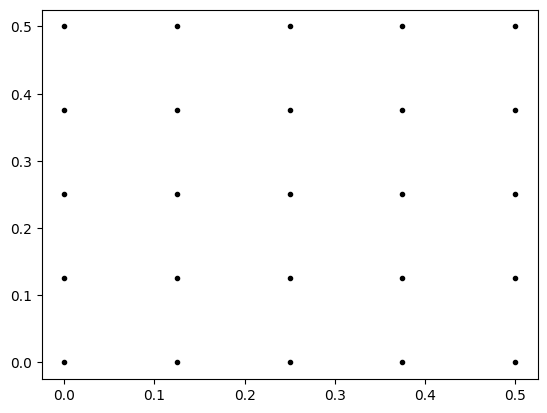

In [ ]:
xx,yy = np.meshgrid(x,y)
plt.plot(xx,yy,'.k')
plt.show()

In [61]:
import numpy as np

# domain size
a, b = 0.5, 0.5

# grid points
m, n = 5,5

x, h = np.linspace(0, a, m, retstep=True)
y, k = np.linspace(0, b, n, retstep=True)

Nx, Ny = m-2, n-2
N = Nx * Ny

A = np.zeros((N, N))
b_vec = np.zeros(N)

def idx(i, j):
    return j*Nx + i

# boundary conditions
phi_top = 200 * x[1:-1]
phi_bottom = np.zeros(n-2)
phi_left = np.zeros(m-2)
phi_right = 200 * y[1:-1]

# build system
for i in range(Nx):
    for j in range(Ny):
        k_ind = idx(i, j)

        A[k_ind, k_ind] = -(2/h**2 + 2/k**2)

        # DOWN
        if i > 0:
            A[k_ind, idx(i-1, j)] = 1/h**2
        else:
            b_vec[k_ind] -= phi_bottom[j] / h**2

        # UP
        if i < Nx-1:
            A[k_ind, idx(i+1, j)] = 1/h**2
        else:
            b_vec[k_ind] -= phi_top[j] / h**2

        # LEFT
        if j > 0:
            A[k_ind, idx(i, j-1)] = 1/k**2
        else:
            b_vec[k_ind] -= phi_left[i] / k**2

        # RIGHT
        if j < Ny-1:
            A[k_ind, idx(i, j+1)] = 1/k**2
        else:
            b_vec[k_ind] -= phi_right[i] / k**2

# solve
phi_vec = np.linalg.solve(A, b_vec)
phi_interior = phi_vec.reshape((Nx, Ny))

# full grid
phi_full = np.zeros((m, n))
phi_full[1:-1, 1:-1] = phi_interior

phi_full[0, 1:-1] = phi_bottom
phi_full[-1, 1:-1] = phi_top
phi_full[1:-1, 0] = phi_left
phi_full[1:-1, -1] = phi_right

print(phi_full)

# print(A,b_vec)

[[ 0.    0.    0.    0.    0.  ]
 [ 0.    6.25 12.5  18.75 25.  ]
 [ 0.   12.5  25.   37.5  50.  ]
 [ 0.   18.75 37.5  56.25 75.  ]
 [ 0.   25.   50.   75.    0.  ]]


[[0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 2.08819710e-05 4.75111105e-05 ... 2.08797115e+00
  2.29341065e+00 2.50000000e+00]
 [0.00000000e+00 4.75111105e-05 1.07371354e-04 ... 4.17793024e+00
  4.58782507e+00 5.00000000e+00]
 ...
 [0.00000000e+00 2.08797115e+00 4.17793024e+00 ... 8.91416423e+01
  9.20708071e+01 9.50000000e+01]
 [0.00000000e+00 2.29341065e+00 4.58782507e+00 ... 9.20708071e+01
  9.47854035e+01 9.75000000e+01]
 [0.00000000e+00 2.50000000e+00 5.00000000e+00 ... 9.50000000e+01
  9.75000000e+01 1.00000000e+02]]


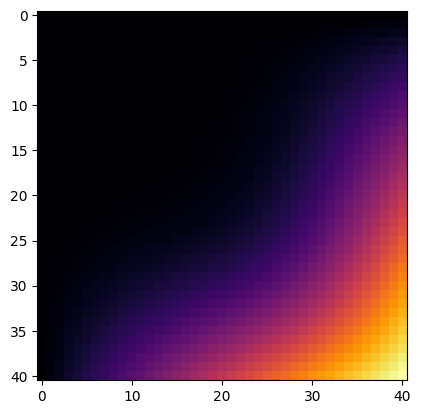

In [82]:
# Using iterative approach
m = 40
n = 40
a,b = 0.5,0.5
x,h = np.linspace(0,a,m+1,endpoint=True,retstep=True)
y,k = np.linspace(0,b,m+1,endpoint=True,retstep=True)
U = np.zeros([m+1,n+1])
U[-1,:] = 200*x
U[:,-1] = 200*y
U[0,:] = 0

max_iter = 100

for _ in range(max_iter):
    for i in range(1,m):
        for j in range(1,n):
            U[i,j] = 0.25*(U[i+1,j]+U[i-1,j]+U[i,j+1]+U[i,j-1])
print(U)        
plt.imshow(U,cmap = "inferno")

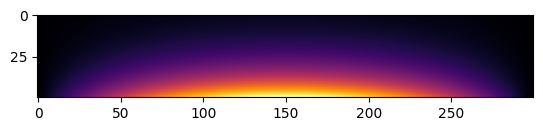

In [143]:
## For diffusion equation:
m,N = 300,50
phi = np.zeros([N,m])
x,h = np.linspace(0,2,m,endpoint=True,retstep = True)
k = 0.1
# phi[-1,:] = np.sin(np.pi*x/2)
phi[-1,:] = np.sin(np.pi*x/2)
phi[:,-1] = 0

r = 0.25*k/(h**2)

A = np.zeros([m-2,m-2])
for i in range(m-2):
    A[i,i] = 1+2*r
    if 0<i<m-3:
        A[i,i-1] = A[i,i+1] = -r
    if i == 0:
        A[i,i+1] = -r
    if i == m-3:
        A[i,i-1] = -r

    
for n in range(1,N)[::-1]:
    phi_curr = solve_linear(A,phi[n,1:-1])
    phi[n-1,1:-1] = phi_curr

plt.imshow(phi,cmap="inferno")
plt.show()

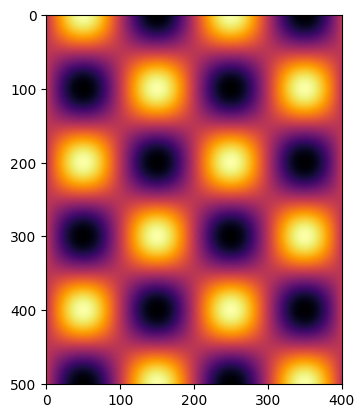

In [78]:
## Solving Wave Equation:

h = 0.01
k = 0.005
lam = 2*k/h
a,T = 4,2.5
x = np.arange(0,a+h,h)
t = np.arange(0,T+k,k)
N = len(t)
m = len(x)
u = np.zeros([N,m])

u[0,:] = np.sin(np.pi*x)
u[:,0] = u[:,-1] = 0

for i in range(1,m-1): 
    u[1,i] = (1-lam)**2*u[0,i] + lam**2/2*(u[0,i+1]+u[0,i-1]) 

for j in range(1,N-1):
    for i in range(1,m-1):
        u[j+1,i] = 2*(1-lam**2)*u[j,i] + lam**2*(u[j,i+1]+u[j,i-1]) - u[j-1,i]

# setup figure
plt.imshow(u,cmap="inferno")

In [237]:
# Find Eigen values:

def gram_schmidt(M:np.ndarray):
    row,col = M.shape
    if row == col:
        O = np.zeros((row,col))
        for i in range(col):
            v = M[:,i].astype(float)
            for j in range(i):
                v = v - np.dot(v,O[:,j])*O[:,j]

            norm = np.linalg.norm(v)
            # if norm < 1e-13:
            #   O[:,i] = 0
            # else:
            #   O[:,i] = v/norm
            O[:,i] = v/norm if norm > 1e-13 else 0
        return O
    else:
        return -1
    
def factorize_QR(M):
    # QR factorization of a matrix using Gram Schmidt process
    u = np.zeros_like(M)
    Q = np.zeros_like(M)
    # Gram-Schmidt using the columns of M
    for k in range(M.shape[0]):
        u[:,k] = M[:,k].copy()
        for i in range(k):
            u[:,k] = u[:,k] - np.dot(M[:,k],Q[:,i])*Q[:,i]
            # np.linalg.norm is simply the L2 norm of the vector. 
        Q[:,k] = u[:,k]/np.linalg.norm(u[:,k])
    R = np.zeros_like(M)
    for i in range(M.shape[0]):
        for j in range(Q.shape[1]):
            R[j,i] = np.dot(M[:,i],Q[:,j])
    return Q, R
    
def QR_decomp(A:np.ndarray):
    Q = gram_schmidt(A)
    R = Q.T@A
    return Q,R

def find_eigval(A):
    U = A.copy()
    max_iter = 200
    for i in range(max_iter):
        Q,R = QR_decomp(U)
        U = R@Q

    return np.diag(U),U



In [229]:
# A = npr.uniform(2,10,(3,3))
# A = np.array([[0.001,1],[1,]])
A = np.double(np.array([[5, 0, 0], [1, 2, 1], [1, 1, 2]]))

In [238]:
find_eigval(A)

(array([5., 3., 1.]),
 array([[ 5.00000000e+00, -1.41421356e+00, -2.37470137e-16],
        [-1.89732392e-16,  3.00000000e+00, -9.35673472e-17],
        [-8.06385856e-32,  1.94685130e-32,  1.00000000e+00]]))

3.14292


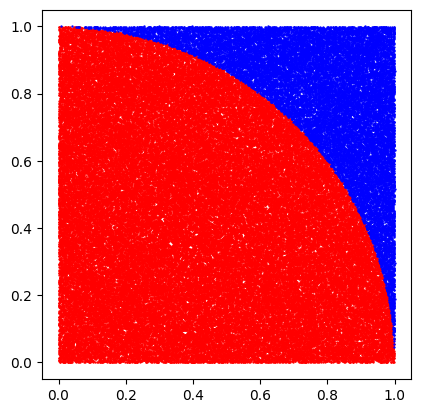

In [265]:
## Monte Carlo Methods:

N = 1e5
x,y = npr.random((2,int(N)))
cond = x**2+y**2 <= 1
x_true,y_true = x[cond],y[cond]
x_false,y_false = x[~cond],y[~cond]

count  = np.sum(cond)
print(4*count/N)

plt.scatter(x_true,y_true,color = 'red',s = 0.5)
plt.scatter(x_false,y_false,color = 'blue',s = 0.5)
plt.gca().set_aspect("equal")

In [345]:
# Markov Chain:
def pi():
    x,y = 0.5,0.5
    N = 10000
    count = 1
    step = 0.75
    for i in range(N):
        dx = npr.uniform(-step,step)
        dy = npr.uniform(-step,step)

        x_new = x+dx
        y_new = y+dy

        if x_new < 0:
            x_new = -x_new
        elif x_new > 1:
            x_new = 2 - x_new

        if y_new < 0:
            y_new = -y_new
        elif y_new > 1:
            y_new = 2 - y_new

        x, y = x_new, y_new
        if x**2+y**2 <= 1:
            count += 1

    return count*4/N

pis = [pi() for i in range(75)]
pi = np.mean(pis)
pi


np.float64(3.1401760000000007)

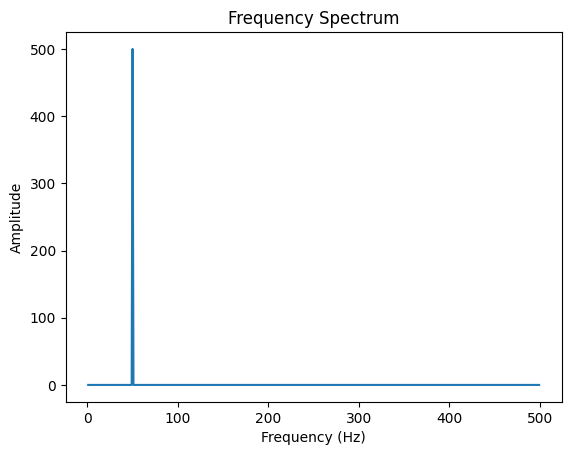

In [359]:
# Sample signal: two sine waves
t = np.linspace(0, 1, 1000, endpoint=False)
signal = np.sin(2*np.pi*50*t)

# FFT
freq = np.fft.fft(signal)
# print(freq)
# Frequency axis
n = len(signal)
dt = t[1] - t[0]

freqs = np.fft.fftfreq(n,dt)
# print(freqs)

# Only take positive frequencies
mask = freqs > 0

plt.plot(freqs[mask], np.abs(freq[mask]))
plt.title("Frequency Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.show()

In [449]:
def adam_bashforth(f,t0,tn,x0,N):
    ts,h = np.linspace(t0,tn,N,retstep=True)

    x_arr = np.zeros(N)
    f_arr = np.zeros(N)

    x_arr[0] = x0
    f_arr[0] = f(ts[0],x_arr[0])
    
    for i in range(3):
        
        k1 = h*f(ts[i],x_arr[i])
        k2 = h*f(ts[i]+0.5*h , x_arr[i] + 0.5*k1)
        k3 = h*f(ts[i]+0.5*h , x_arr[i] + 0.5*k2)
        k4 = h*f(ts[i]+ h, x_arr[i] + k3)
        
        x_arr[i+1] = x_arr[i] + (1/6)*(k1+2*k2+2*k3+k4)
        f_arr[i+1] = f(ts[i+1],x_arr[i+1])
    # print(x_arr)
    for n in range(3,N-1):
        x_arr[n+1] = x_arr[n] + (h/24)*(55*f_arr[n]-59*f_arr[n-1]+37*f_arr[n-2]-9*f_arr[n-3])
        f_arr[n+1] = f(ts[n+1],x_arr[n+1])

        x_arr[n+1] = x_arr[n] + (h/24)*(9*f_arr[n+1]+19*f_arr[n]-5*f_arr[n-1]+f_arr[n-2])
        f_arr[n+1] = f(ts[n+1],x_arr[n+1])

    
    return np.array(x_arr),ts




[1.00000000e+00 9.90039923e-01 9.80179050e-01 9.70416391e-01
 9.60750970e-01 9.51181817e-01 9.41707973e-01 9.32328489e-01
 9.23042426e-01 9.13848853e-01 9.04746848e-01 8.95735500e-01
 8.86813906e-01 8.77981172e-01 8.69236412e-01 8.60578751e-01
 8.52007320e-01 8.43521262e-01 8.35119726e-01 8.26801869e-01
 8.18566859e-01 8.10413871e-01 8.02342087e-01 7.94350698e-01
 7.86438904e-01 7.78605912e-01 7.70850938e-01 7.63173203e-01
 7.55571940e-01 7.48046385e-01 7.40595786e-01 7.33219395e-01
 7.25916474e-01 7.18686290e-01 7.11528120e-01 7.04441245e-01
 6.97424956e-01 6.90478550e-01 6.83601331e-01 6.76792610e-01
 6.70051703e-01 6.63377937e-01 6.56770642e-01 6.50229156e-01
 6.43752824e-01 6.37340996e-01 6.30993031e-01 6.24708292e-01
 6.18486150e-01 6.12325980e-01 6.06227167e-01 6.00189098e-01
 5.94211168e-01 5.88292780e-01 5.82433338e-01 5.76632258e-01
 5.70888956e-01 5.65202858e-01 5.59573395e-01 5.54000001e-01
 5.48482118e-01 5.43019194e-01 5.37610682e-01 5.32256038e-01
 5.26954727e-01 5.217062

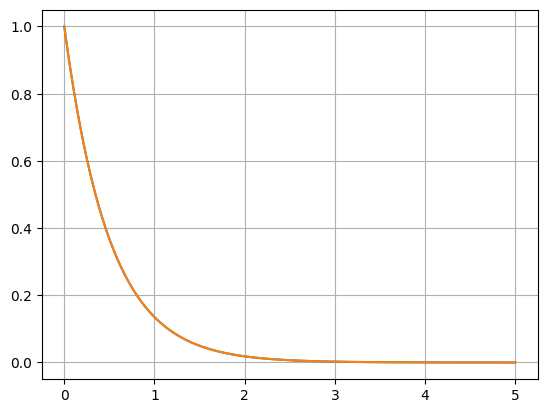

In [450]:
x,t = adam_bashforth(f,0,5,1,1000)
print(x)
plt.plot(t,x)
plt.plot(t,np.exp(-2*t))
plt.grid(1)
plt.show()

Coefficients (beta_0 to beta_3):
[ 1.22142857 -2.16785714  2.08571429 -0.325     ]
[ 1.22142857 -2.16785714  2.08571429 -0.325     ]

Mean Squared Error: 0.00643


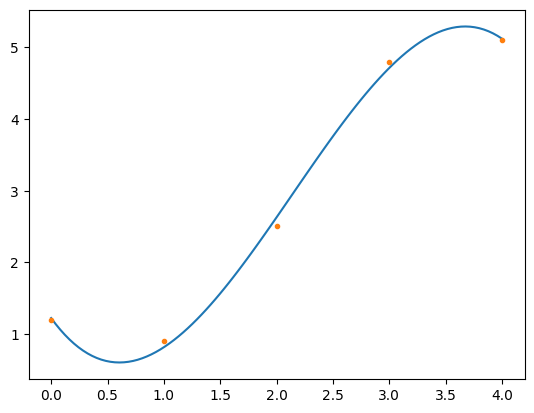

In [459]:
import numpy as np


x = np.array([0, 1, 2, 3, 4])
y = np.array([1.2, 0.9, 2.5, 4.8, 5.1])

X = np.column_stack([x**0, x**1, x**2, x**3])


# 3. The Normal Equation: (X.T * X) * beta = X.T * Y

XTX = X.T @ X
XTY = X.T @ y

beta = np.linalg.solve(XTX, XTY)
beta_numpy = np.polyfit(x, y, 3)

print("Coefficients (beta_0 to beta_3):")
print(beta)
print(beta_numpy[::-1])


x_fit = np.linspace(0, 4, 100)
X_fit = np.column_stack([x_fit**i for i in range(4)])
y_fit = X_fit @ beta


residuals = y - (X @ beta)
mse = np.mean(residuals**2)
print(f"\nMean Squared Error: {mse:.5f}")

plt.plot(x_fit,y_fit)
plt.plot(x,y,'.')
plt.show()